# Georgian Market Data Cleaning Pipeline

This notebook cleans and harmonizes raw financial market data for Georgian and regional market analysis. It combines Yahoo Finance downloads, manually collected FX and index files, sovereign bond prices, and ICE sovereign bond index data, then exports cleaned CSV datasets and a processing manifest.

## 0. Setup

Import the libraries used for data retrieval, cleaning, analysis, and visualization.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## 1. Foreign Exchange Data

Clean Yahoo Finance and manually collected currency data, then convert major regional currency pairs into a consistent GEL-based format.

In [3]:
# Download liquid USD/EUR/GBP exchange-rate series from Yahoo Finance.
ticker = ["EURUSD=X", "GBPUSD=X"]
currencies = yf.download(ticker, start = "2018-01-01", end= "2026-05-09")
currencies = currencies["Close"].copy()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  2 of 2 completed


In [5]:
# Helper for manually collected CSV files that use Date and Price columns.
def CurrencyClean(data, filename):
    """Standardize manually collected FX/index CSV files to a Date index and numeric price column."""
    data['Date'] = pd.to_datetime(data['Date'])
    data = data.sort_values('Date').set_index('Date')
    
    data = data[['Price']].rename(columns={'Price': filename})
    
    data[filename] = (
        data[filename]
        .astype(str)
        .str.replace(',', '', regex=False)
        .astype(float)
    )
    return data

In [7]:
# Load manually collected exchange-rate files and standardize each one.
EURGEL = CurrencyClean(pd.read_csv("Data/EUR_GEL.csv"), 'EURGEL')
USDGEL = CurrencyClean(pd.read_csv("Data/USD_GEL.csv"), 'USDGEL')
GELRUB = CurrencyClean(pd.read_csv("Data/GEL_RUB.csv"), 'GELRUB')
GELTRY = CurrencyClean(pd.read_csv("Data/GEL_TRY.csv"), 'GELTRY')
USDAMD = CurrencyClean(pd.read_csv("Data/USD_AMD.csv"), 'USDAMD')
USDAZN = CurrencyClean(pd.read_csv("Data/USD_AZN.csv"), 'USDAZN')

In [9]:
# Align manual FX data to the Yahoo Finance calendar and merge it with downloaded pairs.
# 4) Align manual data to yfinance dates
EURGEL = EURGEL.reindex(currencies.index).ffill()
USDGEL = USDGEL.reindex(currencies.index).ffill()
GELRUB = GELRUB.reindex(currencies.index).ffill()
GELTRY = GELTRY.reindex(currencies.index).ffill()
USDAMD = USDAMD.reindex(currencies.index).ffill()
USDAZN = USDAZN.reindex(currencies.index).ffill()
# 5) Combine everything into one yfinance-style table
currencies = pd.concat(
    [currencies, EURGEL, USDGEL, GELRUB, GELTRY, USDAMD, USDAZN],
    axis=1
)

currencies = currencies.rename(columns={
    "EURUSD=X": "EURUSD",
    "GBPUSD=X": "GBPUSD"
})

In [11]:
# Build GEL-cross exchange rates. Columns are expressed as GEL per one unit of foreign currency.
FX = pd.DataFrame(index=currencies.index)

FX["USDGEL"] = currencies["USDGEL"]
FX["EURGEL"] = currencies["EURGEL"]
FX["GBPGEL"] = currencies["GBPUSD"] * currencies["USDGEL"]
FX["RUBGEL"] = 1/ currencies["GELRUB"]
FX["TRYGEL"] = 1/ currencies["GELTRY"]
FX["AMDGEL"] = currencies["USDGEL"] / currencies["USDAMD"]
FX["AZNGEL"] = currencies["USDGEL"] / currencies["USDAZN"]

In [13]:
# Engineer FX return, volatility, trend, and broad GEL pressure features.
#log returns
FX_log_returns = np.log(FX / FX.shift(1))

# 30-day rolling volatility
FX_vol_30d = FX_log_returns.rolling(30).std()
FX_vol_30d.columns = [col + "_vol_30d" for col in FX_vol_30d.columns]

# 90-day trend: positive = GEL weaker than recent average
FX_trend_90d = FX / FX.rolling(90).mean() - 1
FX_trend_90d.columns = [col + "_trend_90d" for col in FX_trend_90d.columns]

# GEL FX pressure: positive = broad GEL depreciation pressure
gel_fx_pressure = FX_log_returns.mean(axis=1).to_frame("gel_fx_pressure")

# FX feature matrix
fx_features = pd.concat(
    [FX_log_returns, FX_vol_30d, FX_trend_90d, gel_fx_pressure],
    axis=1
)

fx_features.dropna().head()

,USDGEL,EURGEL,GBPGEL,RUBGEL,TRYGEL,AMDGEL,AZNGEL,USDGEL_vol_30d,EURGEL_vol_30d,GBPGEL_vol_30d,...,AMDGEL_vol_30d,AZNGEL_vol_30d,USDGEL_trend_90d,EURGEL_trend_90d,GBPGEL_trend_90d,RUBGEL_trend_90d,TRYGEL_trend_90d,AMDGEL_trend_90d,AZNGEL_trend_90d,gel_fx_pressure
Date,,,,,,,,,,,,,,,,,,,,,
2018-05-04,-0.002047,-0.004384,-0.002156,0.005913,-0.004573,-0.002047,-0.002047,0.004590,0.006035,0.006628,...,0.005294,0.004600,-0.005254,-0.030450,-0.031232,-0.077039,-0.085669,-0.013241,-0.009270,-0.001620
2018-05-07,-0.004107,-0.007246,-0.007088,-0.010720,-0.013709,-0.004930,-0.004107,0.004658,0.006010,0.006676,...,0.005364,0.004667,-0.008693,-0.036750,-0.037486,-0.085426,-0.096342,-0.017419,-0.012681,-0.007415
2018-05-08,0.000000,-0.004849,0.002832,-0.004776,-0.015798,-0.001233,0.000000,0.004657,0.006040,0.006544,...,0.005363,0.004667,-0.008063,-0.040616,-0.034207,-0.088259,-0.108543,-0.017951,-0.012040,-0.003403
2018-05-09,0.000000,-0.001173,-0.001248,0.002909,0.010504,0.000000,0.000000,0.004651,0.005866,0.006498,...,0.005363,0.004661,-0.007501,-0.041048,-0.034845,-0.084096,-0.097357,-0.017338,-0.011465,0.001570
2018-05-10,0.001234,0.006639,0.000583,0.022709,0.013520,0.001748,-0.000234,0.004428,0.005960,0.006033,...,0.005191,0.004437,-0.005657,-0.033919,-0.033725,-0.061631,-0.083224,-0.014955,-0.010982,0.006600


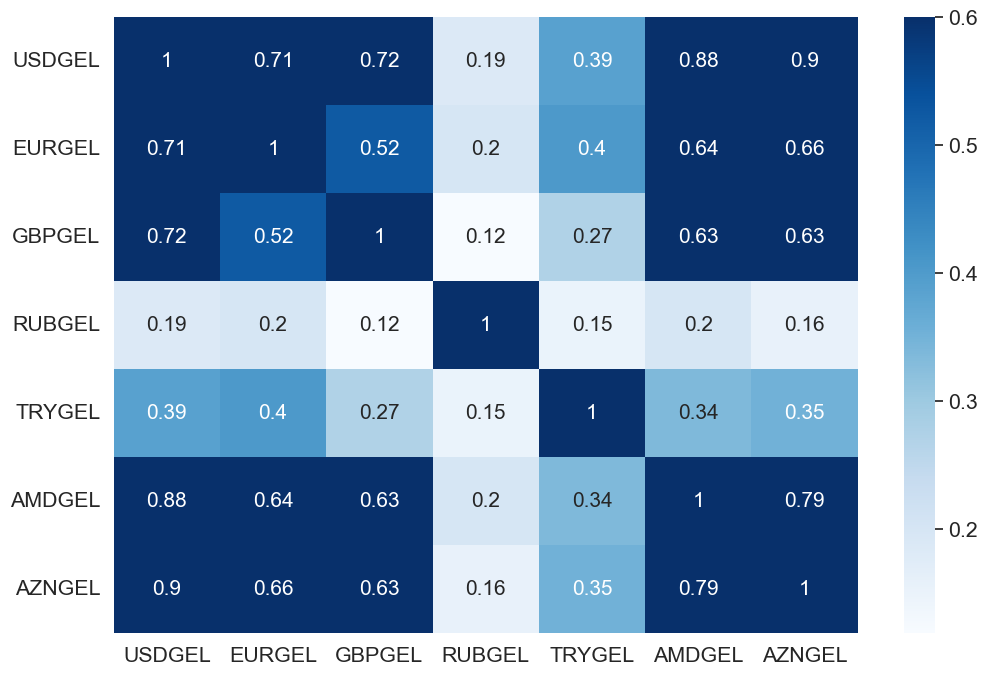

In [15]:
# Correlation check for daily FX returns.
plt.figure(figsize=(12,8))
sns.set(font_scale=1.4)
sns.heatmap(FX_log_returns.corr(), cmap="Blues", annot=True, annot_kws={"size":15}, vmax =0.6)
plt.show()

## 2. TIBR Interest Rate Data

Clean the local TIBR rate series and prepare it as a date-indexed time series.

In [17]:
# Load the TIBR file and remove duplicate observations by date.
TIBR = pd.read_csv("Data/TIBR.csv")
TIBR = TIBR.drop_duplicates(subset=['Date'])

In [19]:
# Convert dates, sort chronologically, and drop identifier columns.
TIBR['Date'] = pd.to_datetime(TIBR['Date'])
TIBR = TIBR.sort_values('Date').set_index('Date').drop(columns=['Id','TIBRCI'])

,TIBR,TIBR1M,TIBR3M,TIBR6M
Date,,,,
2026-05-01,8.00,8.0241,8.0758,8.1571
2026-05-04,8.00,8.0222,8.0766,8.1589
2026-05-05,8.00,8.0231,8.0766,8.1589
2026-05-06,8.00,8.0241,8.0766,8.1589
2026-05-07,8.25,8.0325,8.0778,8.1603


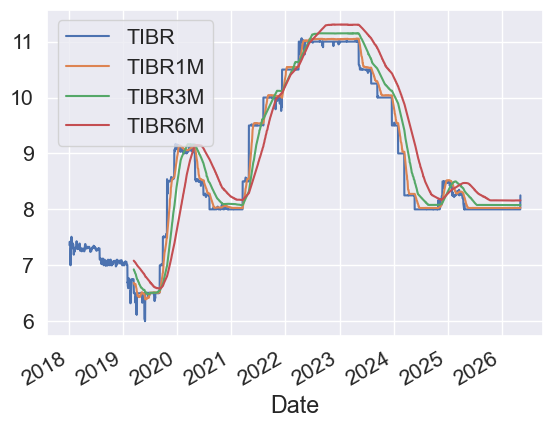

In [21]:
# Quick visual and tail check after cleaning.
TIBR.plot()
TIBR.tail()

## 3. Comparable Equities and Market Benchmarks

Collect Georgian peers, regional benchmarks, commodities, crypto assets, and US yield proxies. Local-currency assets are converted into USD for comparability.

In [7]:
# Define the market tickers used for peer, benchmark, commodity, yield, and crypto data.
banking_dataset = [
    "TBCG.L", "BGEO.L", "CGEO.L",
    "^FTMC",              #FTSE
    "EUFN",               # European Bank Benchmark
    "IXG",                # Global Financials Benchmark
    "EEM",                # MSCI Emerging Markets (ETF Proxy)
    "AKBNK.IS",           # Turkish Peer (Akbank T.A.Ã…Å¾)
    "HSBK.L",             # Kazakh Peer (Halyk Bank)
    "AAZ.L"              # Azerbaijani Company (Anglo Asian Mining PLC)
]
us_yield_tickers = [
    # US Treasuries Yields (10y, 5y, 2y)
    "^TNX", "^FVX", "^IRX"
]

commodity_tickers = [
    # Commodities
    "BZ=F",  # Brent Oil
    "GC=F",  # Gold
    "HG=F"  # Copper
]

crypto_tickers = [
    "BTC-USD",  # BTC
    "ETH-USD",  # ETH
]

cryptos_raw = yf.download(crypto_tickers, start = "2018-01-01", end= "2026-05-09")
equities_raw = yf.download(banking_dataset, start = "2018-01-01", end= "2026-05-09")
yields_raw = yf.download(us_yield_tickers, start = "2018-01-01", end= "2026-05-09")
commodities_raw = yf.download(commodity_tickers, start = "2018-01-01", end= "2026-05-09")

equities = equities_raw["Close"].copy()
yields = yields_raw["Close"].copy()
commodities = commodities_raw["Close"].copy()
cryptos = cryptos_raw["Close"].copy()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  3 of 3 completed


In [85]:
# Rename downloaded tickers into readable column names.
commodities = commodities.rename(columns={
    "BZ=F": "Brent",
    "GC=F": "Gold",
    "HG=F": "Copper"
})

yields = yields.rename(columns={
    "^FVX": "US5Y",
    "^IRX": "US2Y",
    "^TNX": "US10Y"
})

cryptos = cryptos.rename(columns={
    "BTC-USD": "BTC", 
    "ETH-USD": "ETH",  
})

In [27]:
# Load regional equity-index files collected outside Yahoo Finance.
MOEX = CurrencyClean(pd.read_csv("Data/MOEX Russia.csv"), 'MOEX')
BIST = CurrencyClean(pd.read_csv("Data/BIST 100 Turkiye.csv"), 'BIST')

In [29]:
# Derive USD/RUB and USD/TRY from GEL cross rates for local-index conversion.
currencies["USDRUB"] = currencies["USDGEL"] * currencies["GELRUB"]
currencies["USDTRY"] = currencies["USDGEL"] * currencies["GELTRY"]

#Align currencies data to index dates
fx_for_indices = currencies[["USDRUB", "USDTRY"]].copy()

In [31]:
# Convert local-currency regional indices into USD terms.
market_indices_usd = pd.DataFrame(index=MOEX.index)

market_indices_usd["MOEX"] = MOEX["MOEX"] / fx_for_indices["USDRUB"].reindex(MOEX.index).ffill()
market_indices_usd["BIST"] = BIST["BIST"] / fx_for_indices["USDTRY"].reindex(BIST.index).ffill()

In [87]:
# Store securities already denominated in USD.
#Storage for equities denominated in USD
equities_usd = pd.DataFrame(index=equities.index)
usd_tickers = [
    "EUFN",
    "IXG",
    "EEM"
]

for ticker in usd_tickers:
    equities_usd[ticker] = equities[ticker]

In [35]:
# Convert London-listed equities quoted in pence into USD.
#Converting London-listed equities quoted in pence into USD
london_pence_tickers = [
    "TBCG.L",
    "BGEO.L",
    "CGEO.L",
    "HSBK.L",
    "AAZ.L"
]

gbpusd_aligned = currencies["GBPUSD"].reindex(equities.index).ffill()

for ticker in london_pence_tickers:
    equities_usd[ticker.replace(".L", "")] = (
        equities[ticker] / 100 * gbpusd_aligned
    )

In [37]:
# Convert the FTSE index proxy into USD terms.
# FTSE index in USD terms
equities_usd["FTMC"] = equities["^FTMC"] /100 * gbpusd_aligned

In [39]:
# Convert the Turkish peer from TRY into USD.
usdtry_aligned = currencies["USDTRY"].reindex(equities.index).ffill()

equities_usd["AKBNK"] = equities["AKBNK.IS"] / usdtry_aligned

In [41]:
# Combine all equity and market-index levels into one USD-denominated dataset.
all_market_usd = pd.concat(
    [
        equities_usd,
        market_indices_usd.reindex(equities_usd.index).ffill()
    ],
    axis=1
)

In [182]:
# 1. Initialize the dataframe using the common equity index
all_market = pd.DataFrame(index=equities.index)

# 2. Add Regional Indices in their Local Currencies (RUB and TRY)
# We use the raw DataFrames before the FX division was applied
all_market["MOEX"] = MOEX["MOEX"].reindex(all_market.index).ffill()
all_market["BIST"] = BIST["BIST"].reindex(all_market.index).ffill()

usd_tickers = ["EUFN", "IXG", "EEM"]
for ticker in usd_tickers:
    all_market[ticker] = equities[ticker]

# We strip the ".L" to match your previous naming convention
london_tickers = ["TBCG.L", "BGEO.L", "CGEO.L", "HSBK.L", "AAZ.L"]
for ticker in london_tickers:
    clean_name = ticker.replace(".L", "")
    all_market[clean_name] = equities[ticker]

all_market["FTMC"] = equities["^FTMC"]

all_market["AKBNK"] = equities["AKBNK.IS"]

all_market = all_market.sort_index().ffill(limit=5)

## 4. Publicly Traded Sovereign Bonds

Standardize bond metadata and price files, fill internal price gaps, compute bond returns, and estimate yield-to-maturity series.

In [47]:
# Load static bond metadata used for yield-to-maturity calculations.
bond_info =  pd.read_csv("Data/bond_metadata.csv")

bond_info["maturity_date"] = pd.to_datetime(bond_info["maturity_date"])
bond_info["coupon"] = bond_info["coupon"].astype(float)
bond_info["face_value"] = bond_info["face_value"].astype(float)
bond_info["coupon_frequency"] = bond_info["coupon_frequency"].astype(int)
bond_info = bond_info.set_index("isin")
bond_info


,issuer,ticker,currency,coupon,maturity_date,face_value,coupon_frequency,day_count_basis
isin,,,,,,,,
US900123BB58,Turkey,TURKEY_38_725,USD,7.250,2038-03-05,100.0,2,30/360
US900123AY60,Turkey,TURKEY_36_688,USD,6.875,2036-03-17,100.0,2,30/360
US900123CB40,Turkey,TURKEY_43_488,USD,4.875,2043-04-16,100.0,2,30/360
RU000A0JXU14,Russia,RUSSIA_47_525,USD,5.250,2047-06-23,100.0,2,30/360
XS0767473852,Russia,RUSSIA_42_563,USD,5.625,2042-04-04,100.0,2,30/360
XS0088543193,Russia,RUSSIA_28_1275,USD,12.750,2028-06-24,100.0,2,30/360
RU000A1006S9,Russia,RUSSIA_35_510,USD,5.100,2035-03-28,100.0,2,30/360
XS3020792696,Armenia,ARMEN_35_675,USD,6.750,2035-03-12,100.0,2,30/360
XS2010028939,Armenia,ARMEN_31_360,USD,3.600,2031-02-02,100.0,2,30/360


In [49]:
# Helper for cleaning one bond price CSV into a Date-indexed ISIN series.
def clean_bond_price(file_path):
    """Clean one bond price CSV and return a Date-indexed price series named by ISIN."""
    isin = os.path.basename(file_path).replace(".csv", "")
    
    data = pd.read_csv(file_path)
    data["Date"] = pd.to_datetime(data["Date"])
    
    data.columns = data.columns.str.strip()

    target_col = "Close" if "Close" in data.columns else "Price"
    data = data[["Date", target_col]].copy()
    
    data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
    
    # Clean price
    data[isin] = (
        data[target_col]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    
    data[isin] = pd.to_numeric(data[isin], errors="coerce")

    data = data.dropna(subset=["Date", isin])
    
    # some of the prices are quoted in percentage terms
    if data[isin].mean() < 5:
        data[isin] = data[isin] * 100
    
    data = data.sort_values("Date").drop_duplicates("Date", keep="last")
    data = data.set_index("Date")
    
    return data[[isin]]

In [51]:
# Read every available bond price file and combine the cleaned series into one table.
price_folder = "Data/Bonds/"

price_dfs = []

for isin in bond_info.index:
    file_path = os.path.join(price_folder, f"{isin}.csv")
    
    if os.path.exists(file_path):
        price_dfs.append(clean_bond_price(file_path))
    else:
        print(f"Missing file for {isin}")

bond_prices = pd.concat(price_dfs, axis=1).sort_index()
bond_prices.head()

,US900123BB58,US900123AY60,US900123CB40,RU000A0JXU14,XS0767473852,XS0088543193,RU000A1006S9,XS3020792696,XS2010028939,XS2010043904,XS1678623734,XS1678623064,XS2808539410,XS2334109423,XS3262542155,XS2801343414
Date,,,,,,,,,,,,,,,,
2018-01-01,NaN,NaN,NaN,104.93,111.88,173.625,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-02,116.48,111.70,88.20,104.29,112.12,173.625,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,116.92,112.22,88.50,104.89,112.25,173.750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-04,116.97,112.17,88.45,105.88,112.62,173.875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-05,117.12,112.40,88.81,105.20,112.75,174.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
# Fill missing observations only between each bond series first and last available price.
#fill the missing price data
bond_prices_filled = bond_prices.copy()

for col in bond_prices_filled.columns:
    first_valid = bond_prices_filled[col].first_valid_index()
    last_valid = bond_prices_filled[col].last_valid_index()
    
    if first_valid is not None and last_valid is not None:
        bond_prices_filled.loc[first_valid:last_valid, col] = (
            bond_prices_filled.loc[first_valid:last_valid, col]
            .ffill()
        )

In [55]:
# Estimate annualized yield to maturity by solving the present-value equation.
from scipy.optimize import brentq

def calculate_ytm(price, coupon, maturity_date, settlement_date, face_value=100, frequency=2):
    """Estimate annualized yield to maturity from clean price and bond metadata."""
    
    if pd.isna(price):
        return np.nan
    
    maturity_date = pd.to_datetime(maturity_date)
    settlement_date = pd.to_datetime(settlement_date)
    
    years = (maturity_date - settlement_date).days / 365.25
    
    if years <= 0:
        return np.nan
    
    periods = int(np.ceil(years * frequency))
    coupon_payment = face_value * coupon / 100 / frequency
    
    def bond_price_difference(y):
        pv_coupons = sum(
            coupon_payment / (1 + y / frequency) ** t
            for t in range(1, periods + 1)
        )
        
        pv_face_value = face_value / (1 + y / frequency) ** periods
        
        return pv_coupons + pv_face_value - price
    
    try:
        return brentq(bond_price_difference, -0.99, 3.00)
    except:
        return np.nan

In [57]:
# Calculate yield-to-maturity for each bond price observation.
bond_yields = pd.DataFrame(index=bond_prices_filled.index)

for isin in bond_prices_filled.columns:
    
    info = bond_info.loc[isin]
    
    # Skip perpetual / AT1 bonds
    if pd.to_datetime(info["maturity_date"]).year >= 2099:
        print(f"Skipping AT1/perpetual bond: {isin}")
        bond_yields[isin] = np.nan
        continue
    
    bond_yields[isin] = [
        calculate_ytm(
            price=price,
            coupon=info["coupon"],
            maturity_date=info["maturity_date"],
            settlement_date=date,
            face_value=info["face_value"],
            frequency=info["coupon_frequency"]
        )
        for date, price in bond_prices_filled[isin].items()
    ]

bond_yields_pct = bond_yields * 100

bond_yields_pct.head()

,US900123BB58,US900123AY60,US900123CB40,RU000A0JXU14,XS0767473852,XS0088543193,RU000A1006S9,XS3020792696,XS2010028939,XS2010043904,XS1678623734,XS1678623064,XS2808539410,XS2334109423,XS3262542155,XS2801343414
Date,,,,,,,,,,,,,,,,
2018-01-01,NaN,NaN,NaN,4.931120,4.795535,4.065400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-02,5.858547,5.832793,5.763836,4.971256,4.780079,4.065400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,5.825325,5.790039,5.739157,4.933618,4.771726,4.055143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-04,5.821561,5.794138,5.743262,4.872202,4.748026,4.044896,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-05,5.810282,5.775303,5.713782,4.914296,4.739725,4.034658,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='Date'>

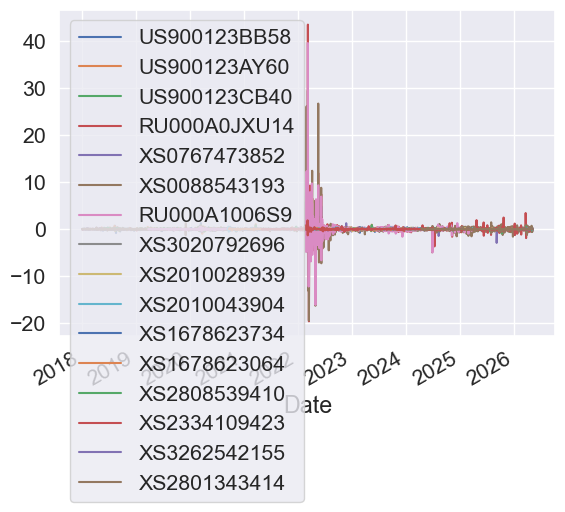

In [58]:
bond_yields_pct.diff().plot()

## 5. ICE Sovereign Bond Indices

Clean ICE sovereign bond price and total-return index files for Georgian, regional, and benchmark market series.

In [59]:
# Helper for cleaning one ICE index CSV into Date-indexed numeric index levels.
ice_tickers = [
    "G0GE", "G1GE", "G2GE", "G3GE", "G4GE", "GAGE",
    "GDAM", "GDAZ", "GDGE", "GDRU", "GDTR", "GJGE"
]

def clean_ice_file(file_path):
    """Clean one ICE index CSV and return Date-indexed numeric index levels."""
    file_name = os.path.basename(file_path).replace(".csv", "")
    
    data = pd.read_csv(file_path)
    data.columns = data.columns.str.strip()
    
    # Remove useless unnamed columns
    data = data.loc[:, ~data.columns.str.contains("^Unnamed")]
    
    # First column is Date
    date_col = data.columns[0]
    data[date_col] = pd.to_datetime(data[date_col], errors="coerce")
    data = data.rename(columns={date_col: "Date"})
    
    # All columns except Date
    value_cols = [col for col in data.columns if col != "Date"]
    
    # Keep only ICE ticker columns if they exist
    ticker_cols = [col for col in value_cols if col in ice_tickers]
    
    if len(ticker_cols) > 0:
        data = data[["Date"] + ticker_cols].copy()
    else:
        # If no ticker column exists, keep only the first value column and rename it to file name
        data = data[["Date", value_cols[0]]].copy()
        data = data.rename(columns={value_cols[0]: file_name})
    
    # Clean numeric columns
    for col in data.columns:
        if col != "Date":
            data[col] = (
                data[col]
                .astype(str)
                .str.replace(",", "", regex=False)
                .str.replace("%", "", regex=False)
                .str.strip()
            )
            data[col] = pd.to_numeric(data[col], errors="coerce")
    
    data = data.dropna(subset=["Date"])
    data = data.sort_values("Date").drop_duplicates("Date", keep="last")
    data = data.set_index("Date")
    
    return data

In [60]:
# Clean and combine ICE price-index files.
ice_prices_folder = "Data/ICE/Prices"

ice_dfs = []

for file in os.listdir(ice_prices_folder):
    if file.endswith(".csv"):
        file_path = os.path.join(ice_prices_folder, file)
        ice_dfs.append(clean_ice_file(file_path))

ice_price_levels = pd.concat(ice_dfs, axis=1).sort_index()

ice_price_levels.head()

,G0GE,G1GE,G2GE,G3GE,G4GE,GAGE,GDAM,GDAZ,GDGE,GDRU,GDTR,GJGE
Date,,,,,,,,,,,,
2016-05-06,NaN,NaN,NaN,NaN,NaN,NaN,98.14,96.02,110.13,118.21,110.09,NaN
2016-05-09,NaN,NaN,NaN,NaN,NaN,NaN,98.12,96.27,110.13,118.32,110.21,NaN
2016-05-10,NaN,NaN,NaN,NaN,NaN,NaN,98.25,96.27,110.13,118.29,110.42,NaN
2016-05-11,NaN,NaN,NaN,NaN,NaN,NaN,98.37,96.52,110.13,118.44,110.54,NaN
2016-05-12,NaN,NaN,NaN,NaN,NaN,NaN,98.55,97.52,110.38,118.91,110.88,NaN


In [61]:
# Clean and combine ICE total-return index files.
ice_returns_folder = "Data/ICE/Returns"

ice_dfs = []

for file in os.listdir(ice_returns_folder):
    if file.endswith(".csv"):
        file_path = os.path.join(ice_returns_folder, file)
        ice_dfs.append(clean_ice_file(file_path))

ice_tri_levels = pd.concat(ice_dfs, axis=1).sort_index()

ice_tri_levels.head()

,G0GE,G1GE,G2GE,G3GE,G4GE,GAGE,GDAM,GDAZ,GDGE,GDRU,GDTR,GJGE
Date,,,,,,,,,,,,
2016-05-06,NaN,NaN,NaN,NaN,NaN,NaN,108.907,105.823,203.418,594.154,596.153,NaN
2016-05-09,NaN,NaN,NaN,NaN,NaN,NaN,108.952,106.140,203.523,594.982,597.108,NaN
2016-05-10,NaN,NaN,NaN,NaN,NaN,NaN,109.114,106.154,203.558,594.913,598.277,NaN
2016-05-11,NaN,NaN,NaN,NaN,NaN,NaN,109.261,106.442,203.593,595.785,599.056,NaN
2016-05-12,NaN,NaN,NaN,NaN,NaN,NaN,109.488,107.552,204.088,598.198,600.970,NaN


In [67]:
def fill_small_gaps(df, limit=5):
    df_filled = df.copy()
    
    for col in df_filled.columns:
        first_valid = df_filled[col].first_valid_index()
        last_valid = df_filled[col].last_valid_index()
        
        if first_valid is not None and last_valid is not None:
            df_filled.loc[first_valid:last_valid, col] = (
                df_filled.loc[first_valid:last_valid, col]
                .ffill(limit=limit)
            )
    
    return df_filled

In [69]:
ice_price_levels_filled = fill_small_gaps(ice_price_levels, limit=5)
ice_tri_levels_filled = fill_small_gaps(ice_tri_levels, limit=5)

<Axes: xlabel='Date'>

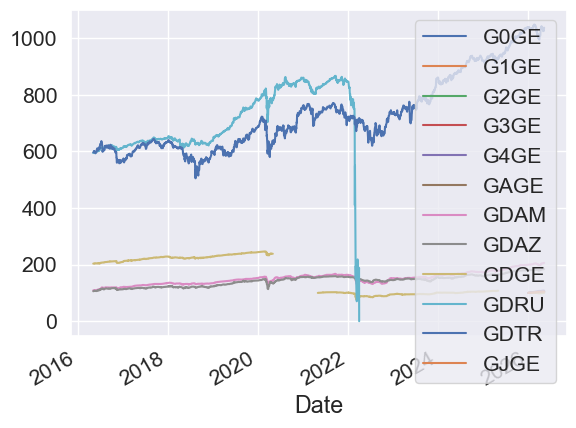

In [71]:
# Visual check of cleaned ICE total-return index levels.
ice_tri_levels.plot()

## 6. Equity Volumes

In [3]:
import xml.etree.ElementTree as ET
#MOEX volume
# Load and parse the XML
tree = ET.parse('Data/MOEX Volume.xml') # or .xml
root = tree.getroot()

data = []
rows = root.findall(".//row")
for row in rows:
    # We only want Date and Value
    date = row.get('TRADEDATE')
    value = row.get('VALUE')
    
    if date and value:
        data.append({
            'Date': pd.to_datetime(date),
            'MOEX': float(value)
        })
        
MOEX_vol = pd.DataFrame(data)
MOEX_vol.set_index('Date', inplace=True)

In [5]:
BIST_vol = pd.read_csv("Data/BIST Volume.csv")
BIST_vol['Date'] = pd.to_datetime(BIST_vol['Date'])
BIST_vol.set_index('Date', inplace=True)
BIST_vol['Volume'] = (
        BIST_vol['Volume']
        .astype(str)
        .str.replace(',', '', regex=False)
        .astype(float)
    )
BIST_vol=BIST_vol.rename(columns={'Volume': 'BIST'})

In [9]:
# 1. Extract Volume only
crypto_vol = cryptos_raw['Volume']
equities_vol = equities_raw['Volume']
commodities_vol = commodities_raw['Volume']


# 2. Combine into one Volume DataFrame
volumes_df = pd.concat([ equities_vol, commodities_vol], axis=1)
volumes_df = volumes_df.dropna()
volumes = pd.concat([volumes_df,crypto_vol,BIST_vol, MOEX_vol], axis=1).dropna()

In [15]:
market_volumes = np.log(volumes / volumes.shift(1)).replace([np.inf, -np.inf], 0).fillna(0).dropna()

D:\Anaconda\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


## 7. Export Processed Datasets

Write the cleaned datasets to Data/Processed and create a manifest with date coverage, shape, and missing-value counts.

In [19]:
# Export all final cleaned datasets and a quality-control manifest.
from pathlib import Path

# Folder where files will be saved
output_folder = Path("Data/Processed")
output_folder.mkdir(parents=True, exist_ok=True)

# Store all final dataframes in one dictionary
datasets = {
    #"FX": FX,
    #"currencies": currencies,
    #"TIBR": TIBR,
    #"cryptos": cryptos,
    #"commodities": commodities,
    #"yields": yields,
    #"all_market": all_market,
    #"bond_prices_filled": bond_prices_filled,
    #"bond_yields_pct": bond_yields_pct,
    #"ice_tri_levels": ice_tri_levels_filled,
    #"ice_price_levels": ice_price_levels_filled,
    "market_volumes": market_volumes
}

# Save each dataframe as CSV
summary = []

for name, df in datasets.items():
    temp = df.copy()
    
    # Make sure index is sorted and named Date
    temp.index = pd.to_datetime(temp.index)
    temp = temp.sort_index()
    temp.index.name = "Date"
    
    # Save CSV
    file_path = output_folder / f"{name}.csv"
    temp.to_csv(file_path, date_format="%Y-%m-%d")
    
    # Save summary info
    summary.append({
        "dataset": name,
        "file": str(file_path),
        "start_date": temp.index.min(),
        "end_date": temp.index.max(),
        "rows": temp.shape[0],
        "columns": temp.shape[1],
        "missing_values": temp.isna().sum().sum()
    })

# Save manifest
manifest = pd.DataFrame(summary)
manifest.to_csv(output_folder / "manifest.csv", index=False)

manifest

,dataset,file,start_date,end_date,rows,columns,missing_values
0,market_volumes,Data\Processed\market_volumes.csv,2018-05-29,2026-05-08,1816,17,0
